# 📊 Strategy Stock Screener

This notebook screens multiple symbols, identifies historical BUY/SELL signals over a 2-year period, visualizes the results, and generates QuickChart links exactly like your LINE bot.

In [1]:
import sys
import urllib.parse
from pathlib import Path

# Add src to Python path
src_path = str(Path().resolve().parent / 'src')
if src_path not in sys.path:
    sys.path.append(src_path)

import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

from screener.config import load_config
from screener.indicators import calculate_stochastic, calculate_rsi, calculate_sma

plt.style.use('dark_background')

In [2]:
# 1. Fetch 2 years of data for a list of symbols
config = load_config()
symbols = config.etf_list[:20]  # Let's test with the first 20 ETFs to keep it fast. You can use the whole list!

print(f"Fetching 2 years of data for {len(symbols)} symbols...")
batch_str = " ".join(symbols)
data = yf.download(batch_str, period="2y", group_by="ticker", auto_adjust=True, progress=False)

print("Data fetched successfully!")

Fetching 2 years of data for 20 symbols...
Data fetched successfully!


In [3]:
# 2. Calculate Indicators & Find Signals for all symbols
historical_signals = {}
latest_matches = []

for ticker in symbols:
    # Handle yfinance multi-index
    df = data[ticker] if len(symbols) > 1 else data
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.get_level_values(0)
    df = df.dropna(how="all").copy()
    
    if len(df) < config.sma_period:
        continue
        
    # Calculate indicators
    stoch = calculate_stochastic(df, config.stochastic_k_period, config.stochastic_d_period)
    rsi = calculate_rsi(df, config.rsi_period)
    sma200 = calculate_sma(df, config.sma_period)
    
    df['stoch_k'] = stoch['stochastic_k']
    df['rsi'] = rsi
    df['sma200'] = sma200
    
    # Define Strategy: Oversold Bounce (BUY)
    # Stoch < 30 AND RSI < 30 AND Price > SMA200
    buy_mask = (df['stoch_k'] < 30) & (df['rsi'] < 30) & (df['Close'] > df['sma200'])
    df['BUY'] = buy_mask
    
    # Define Strategy: Overbought Alert (SELL)
    # Stoch > 70 AND RSI > 70
    sell_mask = (df['stoch_k'] > 70) & (df['rsi'] > 70)
    df['SELL'] = sell_mask
    
    historical_signals[ticker] = df
    
    # Check if it matches TODAY
    if buy_mask.iloc[-1]:
        latest_matches.append({'Ticker': ticker, 'Signal': 'BUY', 'Close': df['Close'].iloc[-1]})
    elif sell_mask.iloc[-1]:
        latest_matches.append({'Ticker': ticker, 'Signal': 'SELL', 'Close': df['Close'].iloc[-1]})

print(f"Processed {len(historical_signals)} symbols.")
pd.DataFrame(latest_matches) if latest_matches else "No signals today!"

Processed 20 symbols.


,Ticker,Signal,Close
0,SPY,SELL,750.460022
1,QQQ,SELL,729.450012
2,XLK,SELL,184.429993


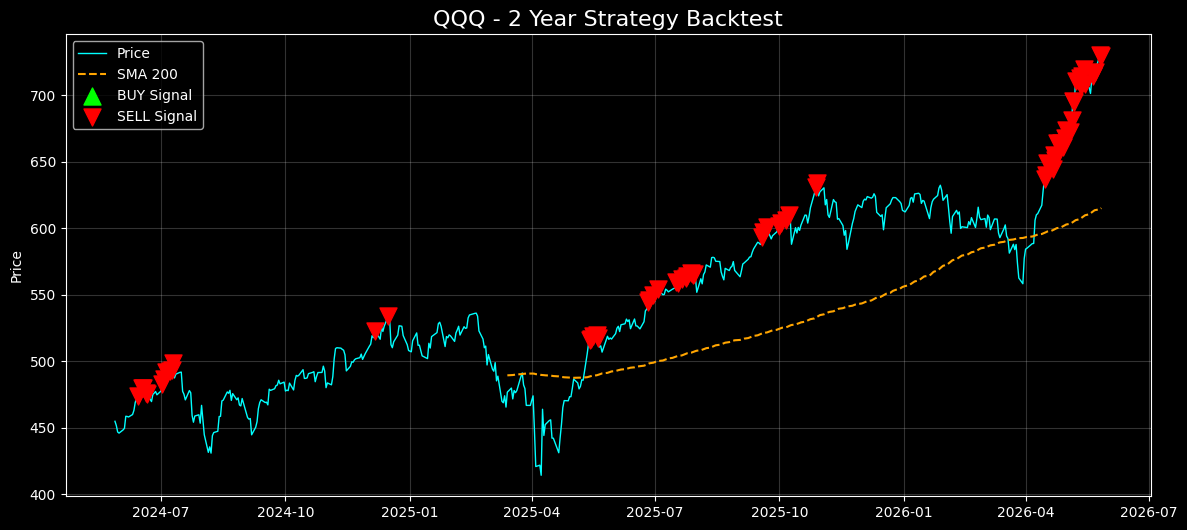

In [5]:
# 3. Plot Historical Signals for a specific symbol
SYMBOL_TO_PLOT = symbols[1]  # Change this to any symbol (e.g. 'SPY', 'QQQ', etc.)

df_plot = historical_signals[SYMBOL_TO_PLOT]
buys = df_plot[df_plot['BUY']]
sells = df_plot[df_plot['SELL']]

plt.figure(figsize=(14, 6))
plt.title(f"{SYMBOL_TO_PLOT} - 2 Year Strategy Backtest", fontsize=16)
plt.plot(df_plot.index, df_plot['Close'], label='Price', color='cyan', linewidth=1)
plt.plot(df_plot.index, df_plot['sma200'], label='SMA 200', color='orange', linestyle='--', linewidth=1.5)

plt.scatter(buys.index, buys['Close'], marker='^', color='lime', s=150, label='BUY Signal', zorder=5)
plt.scatter(sells.index, sells['Close'], marker='v', color='red', s=150, label='SELL Signal', zorder=5)

plt.ylabel("Price")
plt.legend()
plt.grid(alpha=0.2)
plt.show()

In [ ]:
# 4. Generate the exact QuickChart Sparkline used in the LINE Flex Message
def build_quickchart_url(prices: list[float]) -> str:
    if not prices:
        return ""
    data_str = "[" + ",".join(str(p) for p in prices) + "]"
    chart_json = f"{{type:'sparkline',data:{{datasets:[{{data:{data_str},borderColor:'rgba(74,144,226,1)',fill:false}}]}}}}"
    encoded = urllib.parse.quote(chart_json)
    return f"https://quickchart.io/chart?c={encoded}&w=300&h=100"

# Get the last 30 days of close prices for our chosen symbol
recent_prices = [round(float(x), 2) for x in df_plot['Close'].tail(30).tolist()]
qc_url = build_quickchart_url(recent_prices)

print(f"QuickChart URL for {SYMBOL_TO_PLOT} (Click to view):\n")
print(qc_url)

# Display the image right here in the notebook!
from IPython.display import Image, display
display(Image(url=qc_url))